In [2]:
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
new_model = tf.keras.models.load_model(r'C:\Users\Akruti\OneDrive\Documents\REAL TIME FACE MASK\facemask_model.h5')

In [3]:
frame = cv2.imread(r"C:\Users\Akruti\OneDrive\Documents\REAL TIME FACE MASK\DATASET\with_mask\with_mask_2.jpg")

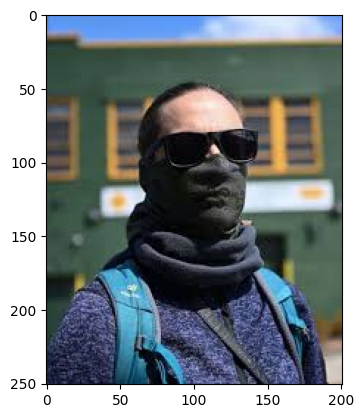

In [4]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [5]:
final_image = cv2.resize(frame, (224,224))
final_image = np.expand_dims(final_image,axis=0)
final_image = final_image/255.0

In [6]:
Predictions = new_model.predict(final_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step


In [7]:
Predictions

array([[6.283451e-06]], dtype=float32)

In [8]:
frame = cv2.imread(r"C:\Users\Akruti\OneDrive\Documents\REAL TIME FACE MASK\DATASET\images.jpg")

In [9]:
frame.shape

(207, 244, 3)

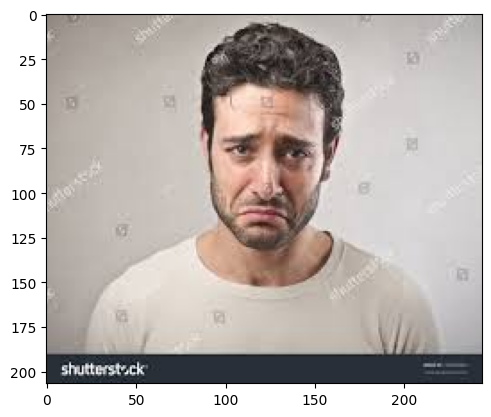

In [10]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [11]:
import os

path = r"C:\Users\Akruti\OneDrive\Documents\REAL TIME FACE MASK\haarcascade_frontalface_default.xml"

print(os.path.exists(path))  # True aana chahiye

faceCascade = cv2.CascadeClassifier(path)

True


In [12]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

In [13]:
gray.shape

(207, 244)

In [14]:
faces = faceCascade.detectMultiScale(gray,1.1,4)
for x,y,w,h in faces:
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = frame[y:y+h, x:x+w]
    cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
    facess = faceCascade.detectMultiScale(roi_gray)
    if len(facess) == 0:
        print("Face not detected")
    else:
        for (ex,ey,ew,eh) in facess:
            face_roi = roi_color[ey: ey+eh, ex:ex + ew]

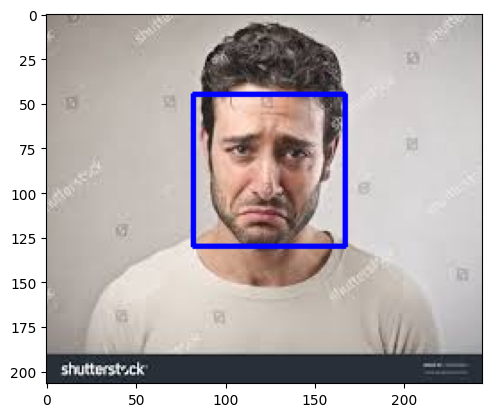

In [15]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

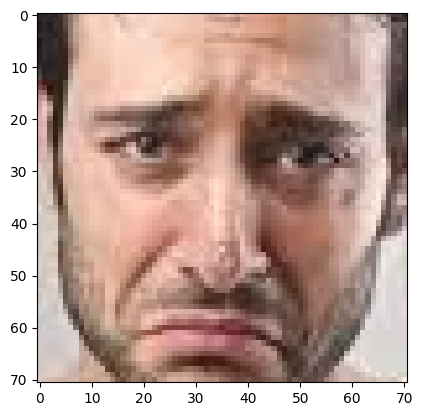

In [16]:
plt.imshow(cv2.cvtColor(face_roi, cv2.COLOR_BGR2RGB))

In [17]:
final_image = cv2.resize(face_roi, (224,224))
final_image = np.expand_dims(final_image,axis=0)
final_image = final_image/255.0

In [18]:
Predictions = new_model.predict(final_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


In [19]:
Predictions

array([[0.99993134]], dtype=float32)

In [ ]:
import cv2
import numpy as np

# ✅ Load cascade ONCE (outside loop)
path = r"C:\Users\Akruti\OneDrive\Documents\REAL TIME FACE MASK\haarcascade_frontalface_default.xml"
faceCascade = cv2.CascadeClassifier(path)

if faceCascade.empty():
    print("❌ Cascade not loaded")
    exit()

# ✅ Camera start
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    cap = cv2.VideoCapture(1)

if not cap.isOpened():
    print("❌ Cannot open camera")
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Frame not read")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # ✅ Detect faces
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        roi_color = frame[y:y+h, x:x+w]

        # ✅ Draw rectangle
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # ✅ Prepare image for model
        final_image = cv2.resize(roi_color, (224, 224))
        final_image = np.expand_dims(final_image, axis=0)
        final_image = final_image / 255.0

        # ✅ Prediction
        Predictions = new_model.predict(final_image)

        # ✅ Label
        if Predictions[0][0] > 0.5:
            status = "No Mask"
            color = (0, 0, 255)
        else:
            status = "Face Mask"
            color = (0, 255, 0)

        # ✅ Display text
        cv2.putText(frame, status, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)

    cv2.imshow('Face Mask Detection', frame)

    if cv2.waitKey(2) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

beeping sound

In [2]:
import cv2
import numpy as np
import winsound

# Beep settings
frequency = 2500
duration = 1000

# Haarcascade path
path = r"C:\Users\Admin\Documents\REAL TIME FACE MASK\haarcascade_frontalface_default.xml"

# Load model (ensure this is already loaded)
# new_model = ...

# Start camera
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise IOError("Cannot open your camera")

# Load face cascade once (not inside loop)
faceCascade = cv2.CascadeClassifier(path)

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Frame not read")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        face_roi = frame[y:y+h, x:x+w]

        # Preprocess
        final_image = cv2.resize(face_roi, (224, 224))
        final_image = np.expand_dims(final_image, axis=0)
        final_image = final_image / 255.0

        # Prediction
        Predictions = new_model.predict(final_image)

        if Predictions[0][0] > 0.5:
            status = "No Mask"
            color = (0, 0, 255)

            # Beep alert
            winsound.Beep(frequency, duration)

        else:
            status = "Mask"
            color = (0, 255, 0)

        # Draw rectangle
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)

        # Label box
        cv2.rectangle(frame, (x, y-40), (x+w, y), color, -1)
        cv2.putText(frame, status, (x+5, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    cv2.imshow("Face Mask Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

OSError: Cannot open your camera